<a href="https://colab.research.google.com/github/HACKERblack25/assignment-01-BITSoM_BA_2511718/blob/main/part4-vector-db/Untitled4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [15]:
!pip install sentence-transformers


In [16]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity

In [17]:
sentences = [
    # Cricket (4 sentences)
    "The batsman hit a powerful six over mid-wicket to win the match.",
    "India won the Test series after a brilliant bowling performance.",
    "The spinner deceived the batsman with a well-disguised googly.",
    "A dropped catch in the slip cordon proved costly for the fielding side.",
    # Cooking (3 sentences)
    "Saute the onions in olive oil until they turn golden brown.",
    "Marinating the chicken overnight enhances its flavour and tenderness.",
    "Always preheat the oven before placing the cake batter inside.",
    # Cybersecurity (3 sentences)
    "A phishing email tricked the employee into revealing their password.",
    "Firewalls and intrusion detection systems protect networks from attacks.",
    "Encrypting sensitive data ensures it cannot be read if intercepted.",
]

labels = [
    "Cricket-1", "Cricket-2", "Cricket-3", "Cricket-4",
    "Cooking-1", "Cooking-2", "Cooking-3",
    "CyberSec-1", "CyberSec-2", "CyberSec-3",
]

for i, (lbl, s) in enumerate(zip(labels, sentences)):
    print(f"[{i:02d}] {lbl:12s} | {s}")


[00] Cricket-1    | The batsman hit a powerful six over mid-wicket to win the match.
[01] Cricket-2    | India won the Test series after a brilliant bowling performance.
[02] Cricket-3    | The spinner deceived the batsman with a well-disguised googly.
[03] Cricket-4    | A dropped catch in the slip cordon proved costly for the fielding side.
[04] Cooking-1    | Saute the onions in olive oil until they turn golden brown.
[05] Cooking-2    | Marinating the chicken overnight enhances its flavour and tenderness.
[06] Cooking-3    | Always preheat the oven before placing the cake batter inside.
[07] CyberSec-1   | A phishing email tricked the employee into revealing their password.
[08] CyberSec-2   | Firewalls and intrusion detection systems protect networks from attacks.
[09] CyberSec-3   | Encrypting sensitive data ensures it cannot be read if intercepted.


In [18]:
model = SentenceTransformer("all-MiniLM-L6-v2")
embeddings = model.encode(sentences, show_progress_bar=True)
print(f"\nEmbedding shape: {embeddings.shape}")  # Expected: (10, 384)


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Batches:   0%|          | 0/1 [00:00<?, ?it/s]


Embedding shape: (10, 384)


In [19]:
cos_sim_matrix = cosine_similarity(embeddings)
print("10x10 Cosine Similarity Matrix:")
print(np.round(cos_sim_matrix, 3))

10x10 Cosine Similarity Matrix:
[[ 1.     0.571  0.43   0.285  0.011  0.043  0.069  0.095  0.057 -0.038]
 [ 0.571  1.     0.358  0.24   0.083  0.031  0.068  0.079  0.138  0.01 ]
 [ 0.43   0.358  1.     0.328  0.105  0.023  0.06   0.308  0.061  0.062]
 [ 0.285  0.24   0.328  1.    -0.061  0.023 -0.05   0.118  0.055  0.025]
 [ 0.011  0.083  0.105 -0.061  1.     0.172  0.277  0.105 -0.044 -0.002]
 [ 0.043  0.031  0.023  0.023  0.172  1.     0.078  0.049  0.004  0.073]
 [ 0.069  0.068  0.06  -0.05   0.277  0.078  1.     0.096  0.042  0.021]
 [ 0.095  0.079  0.308  0.118  0.105  0.049  0.096  1.     0.179  0.15 ]
 [ 0.057  0.138  0.061  0.055 -0.044  0.004  0.042  0.179  1.     0.259]
 [-0.038  0.01   0.062  0.025 -0.002  0.073  0.021  0.15   0.259  1.   ]]


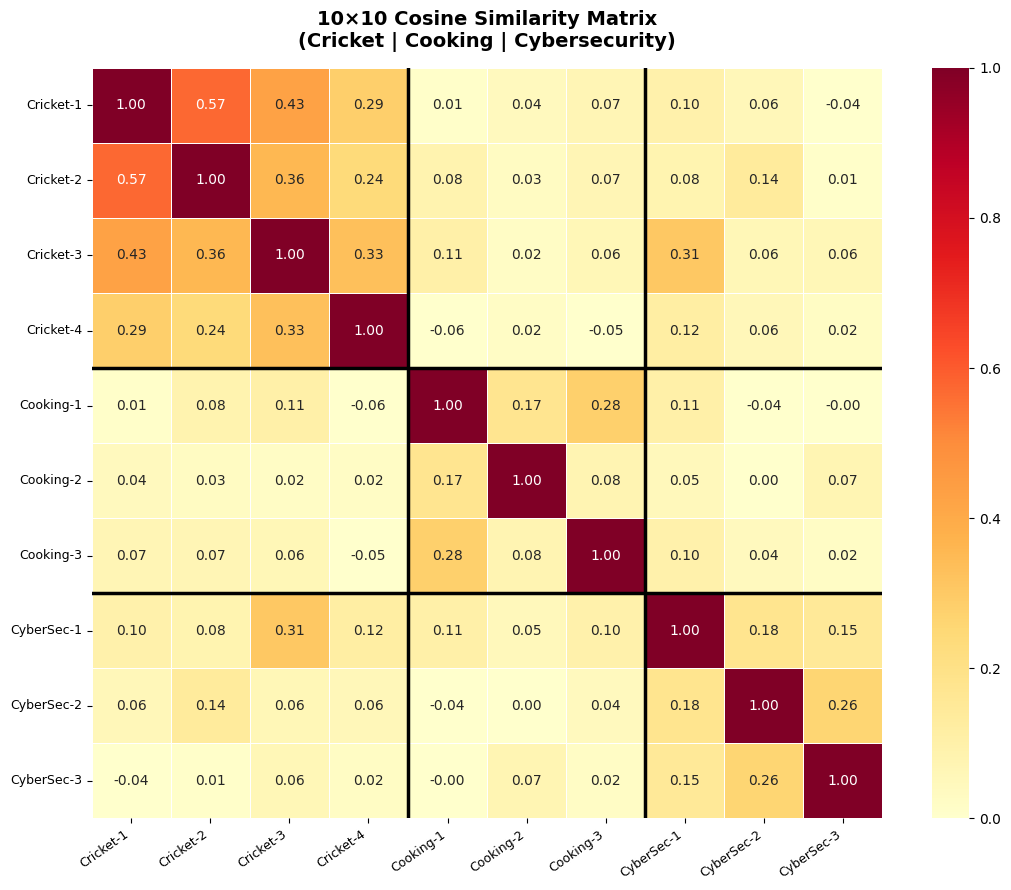

In [20]:
fig, ax = plt.subplots(figsize=(11, 9))

sns.heatmap(
    cos_sim_matrix,
    annot=True,
    fmt=".2f",
    cmap="YlOrRd",
    xticklabels=labels,
    yticklabels=labels,
    linewidths=0.5,
    linecolor="white",
    vmin=0, vmax=1,
    ax=ax
)

# Topic boundary lines
for boundary in [4, 7]:
    ax.axhline(boundary, color="black", linewidth=2.5)
    ax.axvline(boundary, color="black", linewidth=2.5)

ax.set_title("10×10 Cosine Similarity Matrix\n(Cricket | Cooking | Cybersecurity)",
             fontsize=14, fontweight="bold", pad=15)
plt.xticks(rotation=35, ha="right", fontsize=9)
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()
plt.savefig("cosine_similarity_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

In [21]:
query = "The bowler took three wickets in one over"
query_embedding = model.encode([query])
query_sims = cosine_similarity(query_embedding, embeddings)[0]
top2 = np.argsort(query_sims)[::-1][:2]

print(f'Query: "{query}"\n')
print(f"{'Rank':<6} {'Label':<14} {'Score':<8} Sentence")
print("-" * 70)
for rank, idx in enumerate(top2, 1):
    print(f"{rank:<6} {labels[idx]:<14} {query_sims[idx]:.4f}   {sentences[idx]}")

print("\nAll scores:")
print("-" * 70)
for i, (lbl, score) in enumerate(zip(labels, query_sims)):
    bar = "█" * int(score * 30)
    print(f"[{i:02d}] {lbl:12s} | {score:.4f} | {bar}")

Query: "The bowler took three wickets in one over"

Rank   Label          Score    Sentence
----------------------------------------------------------------------
1      Cricket-1      0.6360   The batsman hit a powerful six over mid-wicket to win the match.
2      Cricket-2      0.6067   India won the Test series after a brilliant bowling performance.

All scores:
----------------------------------------------------------------------
[00] Cricket-1    | 0.6360 | ███████████████████
[01] Cricket-2    | 0.6067 | ██████████████████
[02] Cricket-3    | 0.4263 | ████████████
[03] Cricket-4    | 0.2191 | ██████
[04] Cooking-1    | 0.0907 | ██
[05] Cooking-2    | 0.0251 | 
[06] Cooking-3    | 0.0724 | ██
[07] CyberSec-1   | 0.0675 | ██
[08] CyberSec-2   | 0.0195 | 
[09] CyberSec-3   | 0.0109 | 
